# 01 — Data Exploration

**Goal:** Understand the structure, coverage, and quality of our three datasets before cleaning and merging.

**Datasets:**
- **D1** (martj42) — International football results, 1872–2026
- **D2** (patateriedata) — International football results, daily updates
- **D3** (Fjelstul) — FIFA World Cup comprehensive database, 1930–2022

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = Path("../data")

## 1. Load All Datasets

In [2]:
# D1 — martj42 international results
d1_results = pd.read_csv(DATA_DIR / "D1" / "results.csv", parse_dates=["date"])
d1_goalscorers = pd.read_csv(DATA_DIR / "D1" / "goalscorers.csv", parse_dates=["date"])
d1_shootouts = pd.read_csv(DATA_DIR / "D1" / "shootouts.csv", parse_dates=["date"])
d1_former_names = pd.read_csv(DATA_DIR / "D1" / "former_names.csv")

# D2 — patateriedata daily updates
d2_matches = pd.read_csv(DATA_DIR / "D2" / "all_matches.csv", parse_dates=["date"])
d2_country_names = pd.read_csv(DATA_DIR / "D2" / "countries_names.csv")

# D3 — Fjelstul World Cup DB (key files)
d3_matches = pd.read_csv(DATA_DIR / "D3" / "matches.csv")
d3_teams = pd.read_csv(DATA_DIR / "D3" / "teams.csv")
d3_tournaments = pd.read_csv(DATA_DIR / "D3" / "tournaments.csv")
d3_group_standings = pd.read_csv(DATA_DIR / "D3" / "group_standings.csv")
d3_squads = pd.read_csv(DATA_DIR / "D3" / "squads.csv")

print("All datasets loaded.")

All datasets loaded.


## 2. D1 — International Results (martj42)

In [3]:
print(f"Shape: {d1_results.shape}")
print(f"Date range: {d1_results['date'].min()} to {d1_results['date'].max()}")
print(f"\nColumns: {list(d1_results.columns)}")
print(f"\nUnique teams (home): {d1_results['home_team'].nunique()}")
print(f"Unique teams (away): {d1_results['away_team'].nunique()}")
print(f"Unique tournaments: {d1_results['tournament'].nunique()}")
d1_results.head()

Shape: (49215, 9)
Date range: 1872-11-30 00:00:00 to 2026-03-31 00:00:00

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Unique teams (home): 325
Unique teams (away): 318
Unique tournaments: 193


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [4]:
# Missing values
print("Missing values:")
print(d1_results.isnull().sum())
print(f"\nDtype info:")
d1_results.dtypes

Missing values:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Dtype info:


date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

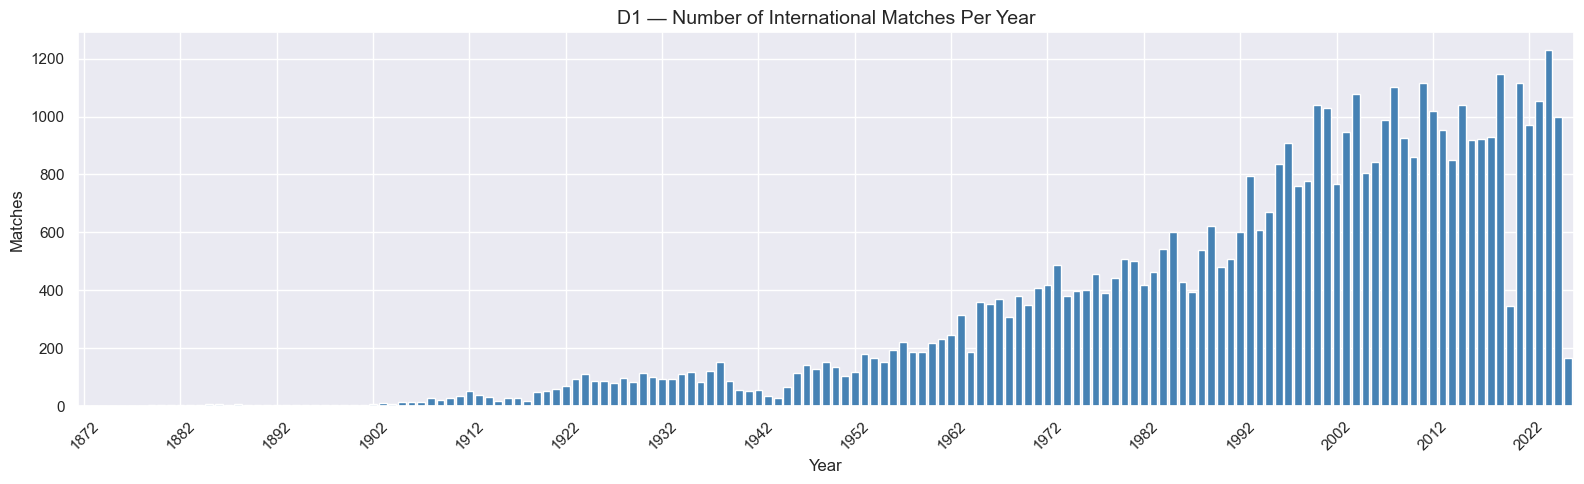

In [5]:
# Matches per year
d1_results['year'] = d1_results['date'].dt.year

fig, ax = plt.subplots(figsize=(16, 5))
d1_results.groupby('year').size().plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('D1 — Number of International Matches Per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Matches')
# Show every 10th year label
ticks = ax.get_xticks()
labels = [item.get_text() for item in ax.get_xticklabels()]
ax.set_xticks(ticks[::10])
ax.set_xticklabels(labels[::10], rotation=45)
plt.tight_layout()
plt.show()

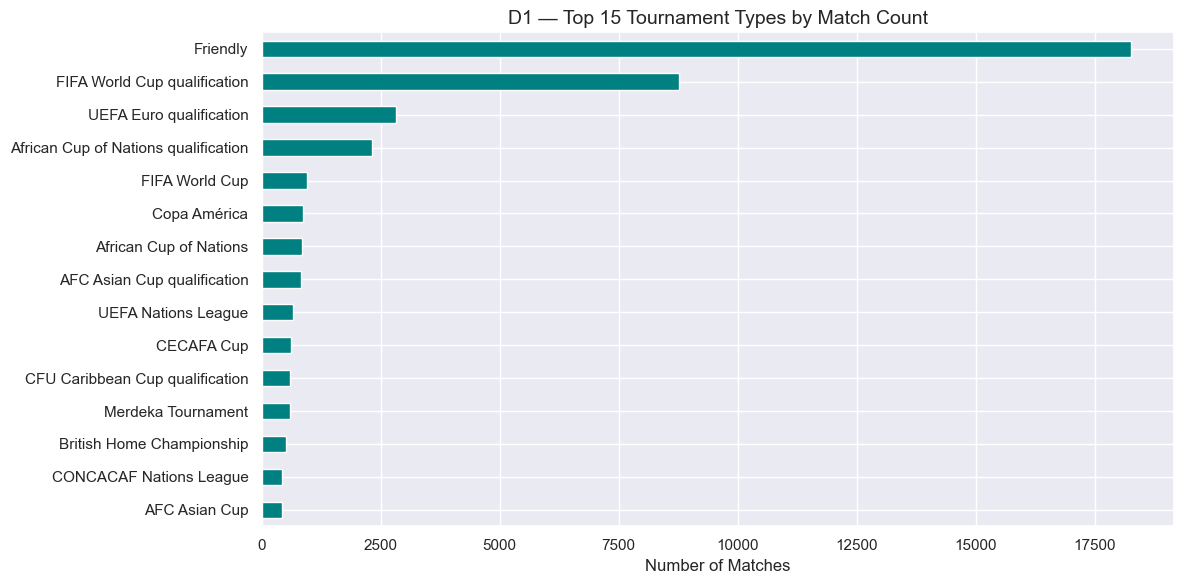

In [6]:
# Top 15 tournament types by match count
top_tournaments = d1_results['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_tournaments.plot(kind='barh', ax=ax, color='teal')
ax.set_title('D1 — Top 15 Tournament Types by Match Count', fontsize=14)
ax.set_xlabel('Number of Matches')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

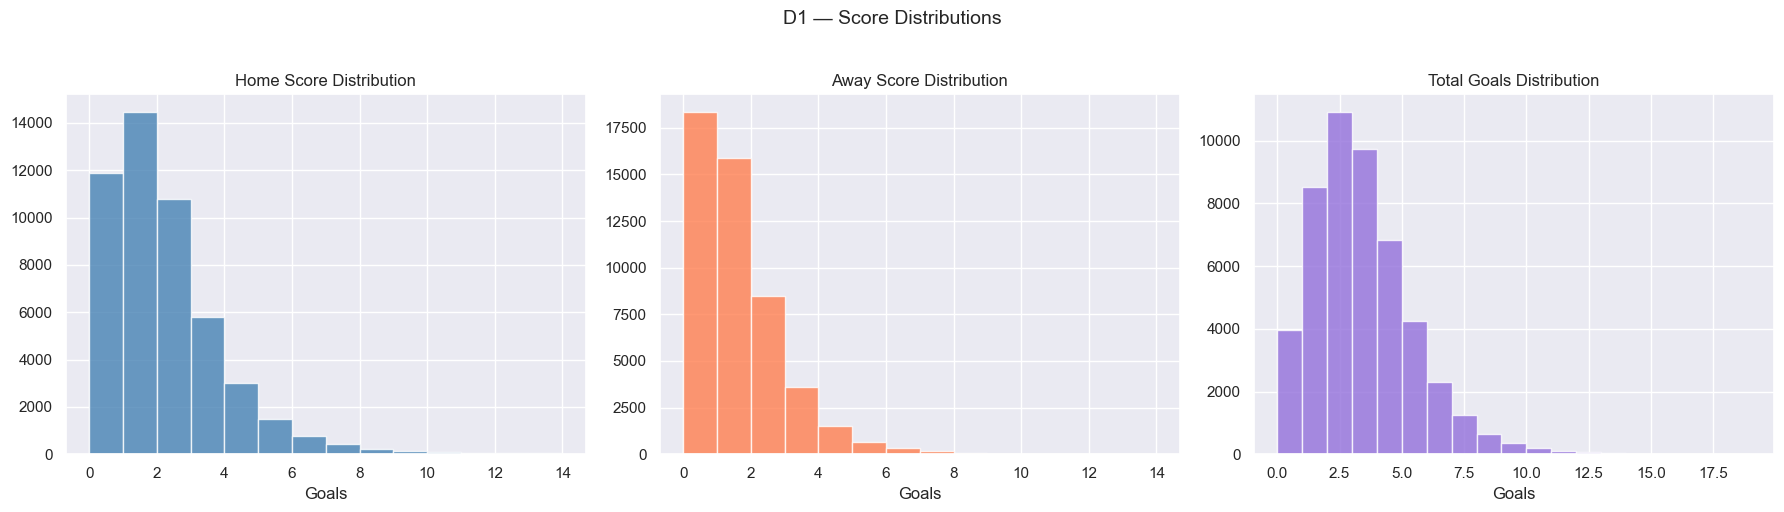

Average home score: 1.76
Average away score: 1.18
Average total goals: 2.94
Home win %: 49.0%
Draw %: 22.8%
Away win %: 28.3%


In [7]:
# Score distribution
d1_results['total_goals'] = d1_results['home_score'] + d1_results['away_score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(d1_results['home_score'], bins=range(0, 15), color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Home Score Distribution')
axes[0].set_xlabel('Goals')

axes[1].hist(d1_results['away_score'], bins=range(0, 15), color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Away Score Distribution')
axes[1].set_xlabel('Goals')

axes[2].hist(d1_results['total_goals'], bins=range(0, 20), color='mediumpurple', edgecolor='white', alpha=0.8)
axes[2].set_title('Total Goals Distribution')
axes[2].set_xlabel('Goals')

plt.suptitle('D1 — Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Average home score: {d1_results['home_score'].mean():.2f}")
print(f"Average away score: {d1_results['away_score'].mean():.2f}")
print(f"Average total goals: {d1_results['total_goals'].mean():.2f}")
print(f"Home win %: {(d1_results['home_score'] > d1_results['away_score']).mean():.1%}")
print(f"Draw %: {(d1_results['home_score'] == d1_results['away_score']).mean():.1%}")
print(f"Away win %: {(d1_results['home_score'] < d1_results['away_score']).mean():.1%}")

In [8]:
# Neutral ground breakdown
neutral_counts = d1_results['neutral'].value_counts()
print(f"Neutral ground matches: {neutral_counts.get(True, 0)} ({neutral_counts.get(True, 0)/len(d1_results):.1%})")
print(f"Home/Away matches: {neutral_counts.get(False, 0)} ({neutral_counts.get(False, 0)/len(d1_results):.1%})")

Neutral ground matches: 12976 (26.4%)
Home/Away matches: 36239 (73.6%)


## 3. D2 — International Results (patateriedata)

In [9]:
print(f"Shape: {d2_matches.shape}")
print(f"Date range: {d2_matches['date'].min()} to {d2_matches['date'].max()}")
print(f"\nColumns: {list(d2_matches.columns)}")
print(f"\nUnique teams (home): {d2_matches['home_team'].nunique()}")
print(f"Unique teams (away): {d2_matches['away_team'].nunique()}")
print(f"Unique tournaments: {d2_matches['tournament'].nunique()}")
d2_matches.head()

Shape: (51485, 8)
Date range: 1872-11-30 00:00:00 to 2026-03-31 00:00:00

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']

Unique teams (home): 278
Unique teams (away): 286
Unique tournaments: 226


,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


In [10]:
# Missing values
print("Missing values:")
print(d2_matches.isnull().sum())

Missing values:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
country       0
neutral       0
dtype: int64


## 4. D1 vs D2 — Overlap Analysis

Both datasets claim to cover international results. We need to understand:
- How much they overlap
- What unique matches each has
- Team name differences between them

In [11]:
# Create match keys for comparison
# Using (date, home_team, away_team) as the key — scores might differ in edge cases
d1_keys = set(zip(d1_results['date'].dt.strftime('%Y-%m-%d'), d1_results['home_team'], d1_results['away_team']))
d2_keys = set(zip(d2_matches['date'].dt.strftime('%Y-%m-%d'), d2_matches['home_team'], d2_matches['away_team']))

overlap = d1_keys & d2_keys
d1_only = d1_keys - d2_keys
d2_only = d2_keys - d1_keys

print(f"D1 total matches: {len(d1_keys):,}")
print(f"D2 total matches: {len(d2_keys):,}")
print(f"\nOverlapping matches: {len(overlap):,}")
print(f"Only in D1: {len(d1_only):,}")
print(f"Only in D2: {len(d2_only):,}")
print(f"\nCombined unique matches: {len(d1_keys | d2_keys):,}")

D1 total matches: 49,214
D2 total matches: 51,407

Overlapping matches: 37,058
Only in D1: 12,156
Only in D2: 14,349

Combined unique matches: 63,563


In [12]:
# Team name differences between D1 and D2
d1_teams = set(d1_results['home_team'].unique()) | set(d1_results['away_team'].unique())
d2_teams = set(d2_matches['home_team'].unique()) | set(d2_matches['away_team'].unique())

print(f"D1 unique teams: {len(d1_teams)}")
print(f"D2 unique teams: {len(d2_teams)}")
print(f"\nTeams only in D1 ({len(d1_teams - d2_teams)}):")
for t in sorted(d1_teams - d2_teams):
    print(f"  - {t}")
print(f"\nTeams only in D2 ({len(d2_teams - d1_teams)}):")
for t in sorted(d2_teams - d1_teams):
    print(f"  - {t}")

D1 unique teams: 333
D2 unique teams: 291

Teams only in D1 (105):
  - Abkhazia
  - Alderney
  - Ambazonia
  - American Samoa
  - Andalusia
  - Arameans Suryoye
  - Artsakh
  - Asturias
  - Aymara
  - Barawa
  - Basque Country
  - Biafra
  - Brittany
  - Canary Islands
  - Cascadia
  - Catalonia
  - Central Spain
  - Chameria
  - Chechnya
  - China PR
  - Cilento
  - Corsica
  - County of Nice
  - Crimea
  - Czech Republic
  - Darfur
  - Donetsk PR
  - Délvidék
  - Elba Island
  - Ellan Vannin
  - Felvidék
  - Franconia
  - Frøya
  - Galicia
  - German DR
  - Gotland
  - Gozo
  - Guernsey
  - Găgăuzia
  - Hitra
  - Hmong
  - Iraqi Kurdistan
  - Isle of Man
  - Isle of Wight
  - Jersey
  - Kabylia
  - Kernow
  - Kárpátalja
  - Luhansk PR
  - Macau
  - Madrid
  - Manchukuo
  - Mapuche
  - Matabeleland
  - Maule Sur
  - Menorca
  - Micronesia
  - Occitania
  - Orkney
  - Padania
  - Panjab
  - Parishes of Jersey
  - Provence
  - Raetia
  - Republic of Ireland
  - Republic of St. Pauli
  -

In [13]:
# Sample D2-only matches to understand what D1 is missing
d2_only_df = d2_matches[
    d2_matches.apply(
        lambda r: (r['date'].strftime('%Y-%m-%d'), r['home_team'], r['away_team']) in d2_only, 
        axis=1
    )
]
print(f"D2-only matches: {len(d2_only_df)}")
print(f"\nTournament breakdown of D2-only matches:")
print(d2_only_df['tournament'].value_counts().head(15))
print(f"\nDate range of D2-only matches: {d2_only_df['date'].min()} to {d2_only_df['date'].max()}")

D2-only matches: 14410

Tournament breakdown of D2-only matches:
Friendly                         4197
World Cup qualifier              1156
Friendly tournament               870
Olympic Games qualifier           735
World Cup                         444
European Championship qual        443
African Nations Cup qualifier     366
Independence Tournament           326
African Nations Cup               300
Asian Cup qualifier               281
CECAFA Cup                        235
Asian Games                       212
COSAFA Cup                        202
Asian Cup                         192
European Championship             183
Name: tournament, dtype: int64

Date range of D2-only matches: 1882-02-18 00:00:00 to 2026-03-31 00:00:00


## 5. D3 — Fjelstul World Cup Database

In [14]:
# Tournaments covered
print(f"Tournaments: {d3_tournaments.shape[0]}")
print(f"Date range: {d3_tournaments['year'].min()} to {d3_tournaments['year'].max()}")
print(f"\nTotal matches: {d3_matches.shape[0]}")
print(f"Total teams ever participated: {d3_teams[d3_teams['mens_team'] == 1].shape[0]}")
print(f"Total players in squads: {d3_squads.shape[0]}")
print(f"\nTournaments:")
d3_tournaments[['tournament_name', 'year', 'host_country', 'winner', 'count_teams']].tail(10)

Tournaments: 30
Date range: 1930 to 2022

Total matches: 1248
Total teams ever participated: 85
Total players in squads: 13843

Tournaments:


,tournament_name,year,host_country,winner,count_teams
20,2003 FIFA Women's World Cup,2003,United States,Germany,16
21,2006 FIFA Men's World Cup,2006,Germany,Italy,32
22,2007 FIFA Women's World Cup,2007,China,Germany,16
23,2010 FIFA Men's World Cup,2010,South Africa,Spain,32
24,2011 FIFA Women's World Cup,2011,Germany,Japan,16
25,2014 FIFA Men's World Cup,2014,Brazil,Germany,32
26,2015 FIFA Women's World Cup,2015,Canada,United States,24
27,2018 FIFA Men's World Cup,2018,Russia,France,32
28,2019 FIFA Women's World Cup,2019,France,United States,24
29,2022 FIFA Men's World Cup,2022,Qatar,Argentina,32


In [15]:
# D3 teams with confederations — this is what we'll use to map confederations
d3_conf = d3_teams[d3_teams['mens_team'] == 1][['team_name', 'confederation_code', 'confederation_name']]
print(f"Teams with confederation data: {len(d3_conf)}")
print(f"\nConfederation breakdown:")
print(d3_conf['confederation_code'].value_counts())
d3_conf.head(10)

Teams with confederation data: 85

Confederation breakdown:
UEFA        39
CAF         13
AFC         12
CONCACAF    11
CONMEBOL     9
OFC          1
Name: confederation_code, dtype: int64


,team_name,confederation_code,confederation_name
0,Algeria,CAF,Confederation of African Football
1,Angola,CAF,Confederation of African Football
2,Argentina,CONMEBOL,South American Football Confederation
3,Australia,AFC,Asian Football Confederation
4,Austria,UEFA,Union of European Football Associations
5,Belgium,UEFA,Union of European Football Associations
6,Bolivia,CONMEBOL,South American Football Confederation
7,Bosnia and Herzegovina,UEFA,Union of European Football Associations
8,Brazil,CONMEBOL,South American Football Confederation
9,Bulgaria,UEFA,Union of European Football Associations


In [16]:
# D3 match detail — what extra info do we get beyond D1/D2?
print("D3 match columns:")
print(list(d3_matches.columns))
print(f"\nExtra time matches: {d3_matches['extra_time'].sum()}")
print(f"Penalty shootouts: {d3_matches['penalty_shootout'].sum()}")
print(f"\nStage breakdown:")
print(d3_matches['stage_name'].value_counts())

D3 match columns:
['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name', 'city_name', 'country_name', 'home_team_id', 'home_team_name', 'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code', 'score', 'home_team_score', 'away_team_score', 'home_team_score_margin', 'away_team_score_margin', 'extra_time', 'penalty_shootout', 'score_penalties', 'home_team_score_penalties', 'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win', 'draw']

Extra time matches: 88
Penalty shootouts: 43

Stage breakdown:
group stage           880
round of 16           113
quarter-finals         70
semi-finals            38
second group stage     36
quarter-final          32
final                  29
third-place match      28
semi-final             16
final round             6
Name: stage_name, dtype: int64


In [17]:
# World Cup winners by tournament — sanity check
print("World Cup Winners:")
for _, row in d3_tournaments.iterrows():
    print(f"  {row['year']} ({row['host_country']}): {row['winner']} — {row['count_teams']} teams")

World Cup Winners:
  1930 (Uruguay): Uruguay — 13 teams
  1934 (Italy): Italy — 16 teams
  1938 (France): Italy — 15 teams
  1950 (Brazil): Uruguay — 13 teams
  1954 (Switzerland): West Germany — 16 teams
  1958 (Sweden): Brazil — 16 teams
  1962 (Chile): Brazil — 16 teams
  1966 (England): England — 16 teams
  1970 (Mexico): Brazil — 16 teams
  1974 (West Germany): West Germany — 16 teams
  1978 (Argentina): Argentina — 16 teams
  1982 (Spain): Italy — 24 teams
  1986 (Mexico): Argentina — 24 teams
  1990 (Italy): West Germany — 24 teams
  1991 (China): United States — 12 teams
  1994 (United States): Brazil — 24 teams
  1995 (Sweden): Norway — 12 teams
  1998 (France): France — 32 teams
  1999 (United States): United States — 16 teams
  2002 (Korea, Japan): Brazil — 32 teams
  2003 (United States): Germany — 16 teams
  2006 (Germany): Italy — 32 teams
  2007 (China): Germany — 16 teams
  2010 (South Africa): Spain — 32 teams
  2011 (Germany): Japan — 16 teams
  2014 (Brazil): Germany

## 6. Team Name Mapping Challenge

D1, D2, and D3 may use different names for the same team. We need a canonical mapping.
D1 provides `former_names.csv`, D2 provides `countries_names.csv`.

In [18]:
# D1 former names
print("D1 former_names.csv:")
print(d1_former_names.to_string(index=False))

D1 former_names.csv:
            current                               former start_date   end_date
              Benin                              Dahomey 1959-11-08 1975-11-30
       Burkina Faso                          Upper Volta 1960-04-14 1984-08-04
            Curaçao                 Netherlands Antilles 1957-03-03 2010-10-10
     Czechoslovakia                              Bohemia 1903-04-05 1919-01-01
     Czechoslovakia                  Bohemia and Moravia 1939-01-01 1945-05-01
     Czechoslovakia Representation of Czechs and Slovaks 1993-03-24 1993-11-17
           DR Congo                        Belgian Congo 1948-05-25 1956-01-02
           DR Congo                   Congo-Léopoldville 1963-04-12 1964-07-19
           DR Congo                       Congo-Kinshasa 1965-01-09 1970-11-24
           DR Congo                                Zaïre 1971-01-10 1997-04-27
           Djibouti                    French Somaliland 1947-12-05 1977-06-27
              Egypt            

In [19]:
# D2 country names — how many have original != current?
d2_name_diff = d2_country_names[d2_country_names['original_name'] != d2_country_names['current_name']]
print(f"D2 country name mappings where original != current: {len(d2_name_diff)}")
print(f"\nSample mappings:")
d2_name_diff[['original_name', 'current_name']].head(20)

D2 country name mappings where original != current: 47

Sample mappings:


,original_name,current_name
20,British Honduras,Belize
22,Dahomey,Benin
23,French Dahomey,Benin
35,Upper Volta,Burkina Faso
37,Ruanda-Urundi,Burundi
39,Khmer Republic,Cambodia
45,Ubangi-Shari,Central African Republic
47,French Sudan,Mali
54,French Congo,Congo
60,Netherlands Antilles,Curaçao


In [20]:
# Check: do D3 team names match D1 team names?
d3_team_names = set(d3_teams[d3_teams['mens_team'] == 1]['team_name'].unique())

# Teams in D3 but not in D1
d3_not_in_d1 = d3_team_names - d1_teams
print(f"D3 teams not found in D1 ({len(d3_not_in_d1)}):")
for t in sorted(d3_not_in_d1):
    print(f"  - {t}")

# Check some known problem names
check_names = ['South Korea', 'Korea Republic', 'Korea DPR', 'North Korea', 
               'Ivory Coast', "Côte d'Ivoire", 'Czech Republic', 'Czechia',
               'China PR', 'China', 'United States', 'USA']
print(f"\nName check across datasets:")
for name in check_names:
    in_d1 = name in d1_teams
    in_d2 = name in d2_teams
    in_d3 = name in d3_team_names
    print(f"  {name:25s} D1={in_d1} D2={in_d2} D3={in_d3}")

D3 teams not found in D1 (7):
  - China
  - Dutch East Indies
  - East Germany
  - Serbia and Montenegro
  - Soviet Union
  - West Germany
  - Zaire

Name check across datasets:
  South Korea               D1=True D2=True D3=True
  Korea Republic            D1=False D2=False D3=False
  Korea DPR                 D1=False D2=False D3=False
  North Korea               D1=True D2=True D3=True
  Ivory Coast               D1=True D2=True D3=True
  Côte d'Ivoire             D1=False D2=False D3=False
  Czech Republic            D1=True D2=False D3=True
  Czechia                   D1=False D2=True D3=False
  China PR                  D1=True D2=False D3=False
  China                     D1=False D2=True D3=True
  United States             D1=True D2=True D3=True
  USA                       D1=False D2=False D3=False


## 7. Summary

Run all cells above and fill in findings below.

In [21]:
print("="*60)
print("DATA EXPLORATION SUMMARY")
print("="*60)
print(f"\nD1 (martj42):")
print(f"  Matches: {len(d1_results):,}")
print(f"  Date range: {d1_results['date'].min().date()} to {d1_results['date'].max().date()}")
print(f"  Columns: {list(d1_results.columns[:9])}")
print(f"  Extra: city column (D2 lacks this)")
print(f"\nD2 (patateriedata):")
print(f"  Matches: {len(d2_matches):,}")
print(f"  Date range: {d2_matches['date'].min().date()} to {d2_matches['date'].max().date()}")
print(f"  Columns: {list(d2_matches.columns)}")
print(f"\nD3 (Fjelstul WC DB):")
print(f"  WC Matches: {len(d3_matches):,}")
print(f"  Tournaments: {len(d3_tournaments)}")
print(f"  Teams with confederation data: {len(d3_conf)}")
print(f"  Players in squads: {len(d3_squads):,}")
print(f"\nOverlap:")
print(f"  D1 ∩ D2: {len(overlap):,} matches")
print(f"  D1 only: {len(d1_only):,} matches")
print(f"  D2 only: {len(d2_only):,} matches")
print(f"  Combined unique: {len(d1_keys | d2_keys):,} matches")
print(f"\nNext step: 02_data_cleaning.ipynb — merge, deduplicate, standardize team names")

DATA EXPLORATION SUMMARY

D1 (martj42):
  Matches: 49,215
  Date range: 1872-11-30 to 2026-03-31
  Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Extra: city column (D2 lacks this)

D2 (patateriedata):
  Matches: 51,485
  Date range: 1872-11-30 to 2026-03-31
  Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']

D3 (Fjelstul WC DB):
  WC Matches: 1,248
  Tournaments: 30
  Teams with confederation data: 85
  Players in squads: 13,843

Overlap:
  D1 ∩ D2: 37,058 matches
  D1 only: 12,156 matches
  D2 only: 14,349 matches
  Combined unique: 63,563 matches

Next step: 02_data_cleaning.ipynb — merge, deduplicate, standardize team names
